# Problem 3: Noise and Error Budget for Long-Range CNOT

This notebook follows the interpretation in Bäumer et al., *Efficient Long-Range Entanglement using Dynamic Circuits*, especially Appendix B.2 and Table I.

The goal is to compare **unitary** and **dynamic** long-range CNOT implementations under two complementary views:

- direct noisy simulation with depolarizing, readout, thermal-relaxation, and combined noise models
- the paper's resource-count error budget

\[
\lambda_{\mathrm{tot}}
= t_{\mathrm{idle}}\lambda_{\mathrm{idle}}
+ N_{\mathrm{CNOT}}\lambda_{\mathrm{CNOT}}
+ N_{\mathrm{meas}}\lambda_{\mathrm{meas}},
\qquad
F_{\mathrm{proc}} \gtrsim e^{-\lambda_{\mathrm{tot}}}.
\]

For CNOT gate teleportation, Table I gives the large-distance comparison used here:

- **Unitary Ic:** `t_idle = 0`, `N_CNOT = 4n + 1`, `N_meas = 0`
- **Dynamic:** `t_idle = 2μ + 2`, `N_CNOT = n + 1`, `N_meas = n`

Here `n` is the number of intermediate ancilla bus qubits. The paper's key intuition is that dynamic circuits become favorable at large `n` when the extra `n` mid-circuit measurements cost less than the extra `3n` CNOT gates of the unitary implementation, roughly `λ_meas < 3 λ_CNOT`.

In [40]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error, thermal_relaxation_error

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dynamic_gates import (  # noqa: E402
    build_cnot_bell_test,
    build_dynamic_cnot,
    build_unitary_cnot_bell_test,
    build_unitary_cnot_ic,
)

plt.style.use("seaborn-v0_8-whitegrid")

## Simulation and Backend-Calibrated Budget Settings

The direct simulation distances are intentionally modest so the notebook can run quickly. The error-budget curves can be evaluated for larger `n` because they use only analytic resource counts.

By default the notebook uses reference-style fallback parameters. To use a backend calibration, set `BACKEND` and `USE_BACKEND_CALIBRATION = True` in the next cell. The extraction supports IBM Runtime backends and fake backends that expose `backend.target` or `backend.properties()`.

The backend usually exposes gate/readout errors, durations, and `T1/T2`, but not always the classical feed-forward latency. If the backend does not expose it, set `FEEDFORWARD_TIME_NS` manually.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

SIM_DISTANCES = [0, 1, 2, 4, 6, 8, 10]
BUDGET_DISTANCES = list(range(0, 41))
BASES = ["XX", "YY", "ZZ"]
IMPLEMENTATIONS = ["dynamic", "unitary_ic"]
SHOTS = 4096
SEED_SIMULATOR = 2026

# Set these two values to pull noise and budget parameters from a backend.
# Real backend example:
#   from qiskit_ibm_runtime import QiskitRuntimeService
#   service = QiskitRuntimeService()
#   BACKEND = service.backend("ibm_sherbrooke")
#   USE_BACKEND_CALIBRATION = True
# Fake backend example:
#   from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
#   BACKEND = FakeSherbrooke()
#   USE_BACKEND_CALIBRATION = True
USE_BACKEND_CALIBRATION = True
service = QiskitRuntimeService()
BACKEND = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
USE_BACKEND_CALIBRATION = True

# Feed-forward latency is often not included in backend calibration data.
# The paper reports roughly 0.7 us for CNOT teleportation on ibm_sherbrooke.
FEEDFORWARD_TIME_NS = 700.0

DEFAULT_NOISE_PARAMS = {
    "p_depol_1q": 1.0e-4,
    "p_depol_2q": 1.0e-2,
    "p_readout": 3.0e-2,
    "t1": 80e3,        # ns
    "t2": 60e3,        # ns
    "time_1q": 50,     # ns
    "time_2q": 300,    # ns
    "time_meas": 800,  # ns
    "time_reset": 800, # ns
}

# Reference-style fallback rates from Fig. 7 of the paper.
DEFAULT_BUDGET_PARAMS = {
    "mu": 3.65,
    "lambda_idle": 0.03,
    "lambda_cnot": 0.02,
    "lambda_meas": 0.03,
}


def _finite_median(values, default=None):
    values = [float(v) for v in values if v is not None and np.isfinite(v) and float(v) > 0]
    if not values:
        return default
    return float(np.median(values))


def _backend_dt_seconds(backend):
    dt = getattr(backend, "dt", None)
    if callable(dt):
        dt = dt()
    return None if dt is None else float(dt)


def _duration_to_ns(value, backend=None):
    """Convert backend duration values to ns.

    IBM backend `properties()` durations are usually seconds, while some
    `target` durations can be integer dt samples. Treat sub-ms floats as
    seconds; treat larger values as dt samples when `backend.dt` exists, and
    otherwise as already being ns-scale values.
    """
    if value is None:
        return None
    value = float(value)
    if not np.isfinite(value) or value <= 0:
        return None
    if value < 1e-3:
        return value * 1e9

    dt_seconds = _backend_dt_seconds(backend)
    if dt_seconds is not None:
        return value * dt_seconds * 1e9
    return value


def _backend_display_name(backend) -> str:
    name = getattr(backend, "name", None)
    return name() if callable(name) else str(name or backend.__class__.__name__)


def _target_property_values(backend, op_names, field: str):
    target = getattr(backend, "target", None)
    if target is None:
        return []

    values = []
    operation_names = set(getattr(target, "operation_names", []))
    for op_name in op_names:
        if op_name not in operation_names:
            continue
        try:
            instruction_properties = target[op_name]
        except Exception:
            continue
        for prop in instruction_properties.values():
            value = getattr(prop, field, None)
            if value is not None:
                values.append(value)
    return values


def _properties_gate_values(backend, gate_names, parameter_name: str):
    try:
        properties = backend.properties()
    except Exception:
        return []
    if properties is None:
        return []

    values = []
    for gate in getattr(properties, "gates", []):
        if getattr(gate, "gate", None) not in gate_names:
            continue
        for param in getattr(gate, "parameters", []):
            if getattr(param, "name", None) == parameter_name:
                values.append(getattr(param, "value", None))
    return values


def _properties_qubit_values(backend, method_name: str):
    try:
        properties = backend.properties()
    except Exception:
        return []
    if properties is None or not hasattr(properties, method_name):
        return []

    values = []
    config_getter = getattr(backend, "configuration", None)
    config = config_getter() if callable(config_getter) else config_getter
    n_qubits = getattr(config, "num_qubits", None)
    if n_qubits is None:
        n_qubits = len(getattr(properties, "qubits", []))
    for qubit in range(n_qubits):
        try:
            values.append(getattr(properties, method_name)(qubit))
        except Exception:
            pass
    return values


def _error_probability_to_lambda(probability: float) -> float:
    """Small-error conversion from calibration probability to Lindblad-style rate."""
    p = min(max(float(probability), 0.0), 1.0 - 1e-12)
    return float(-np.log(1.0 - p))


def _idle_lambda_per_cnot_time(t1_ns: float, t2_ns: float, cnot_time_ns: float) -> float:
    """Appendix-G-inspired idle rate over one two-qubit-gate duration."""
    if min(t1_ns, t2_ns, cnot_time_ns) <= 0:
        return DEFAULT_BUDGET_PARAMS["lambda_idle"]
    return float(cnot_time_ns * (1.0 / (2.0 * t1_ns) + 1.0 / (2.0 * t2_ns)))


def backend_calibration_parameters(
    backend,
    fallback_noise_params: dict,
    fallback_budget_params: dict,
    feedforward_time_ns: float = FEEDFORWARD_TIME_NS,
) -> tuple[dict, dict, pd.DataFrame]:
    """Extract simulator and error-budget parameters from backend calibration data.

    Durations and coherence times are converted to ns. Budget lambda values use
    backend error probabilities as first-order Pauli-Lindblad proxies.
    """
    one_qubit_error = _finite_median(
        _target_property_values(backend, ["sx", "x", "h"], "error")
        + _properties_gate_values(backend, {"sx", "x", "h"}, "gate_error"),
        fallback_noise_params["p_depol_1q"],
    )
    two_qubit_error = _finite_median(
        _target_property_values(backend, ["cx", "ecr", "cz"], "error")
        + _properties_gate_values(backend, {"cx", "ecr", "cz"}, "gate_error"),
        fallback_noise_params["p_depol_2q"],
    )
    readout_error = _finite_median(
        _target_property_values(backend, ["measure"], "error")
        + _properties_qubit_values(backend, "readout_error"),
        fallback_noise_params["p_readout"],
    )

    time_1q_ns = _finite_median(
        [_duration_to_ns(v, backend) for v in _target_property_values(backend, ["sx", "x", "h"], "duration")]
        + [_duration_to_ns(v) for v in _properties_gate_values(backend, {"sx", "x", "h"}, "gate_length")],
        fallback_noise_params["time_1q"],
    )
    time_2q_ns = _finite_median(
        [_duration_to_ns(v, backend) for v in _target_property_values(backend, ["cx", "ecr", "cz"], "duration")]
        + [_duration_to_ns(v) for v in _properties_gate_values(backend, {"cx", "ecr", "cz"}, "gate_length")],
        fallback_noise_params["time_2q"],
    )
    time_meas_ns = _finite_median(
        [_duration_to_ns(v, backend) for v in _target_property_values(backend, ["measure"], "duration")]
        + [_duration_to_ns(v) for v in _properties_qubit_values(backend, "readout_length")],
        fallback_noise_params["time_meas"],
    )
    t1_ns = _finite_median(
        [_duration_to_ns(v) for v in _properties_qubit_values(backend, "t1")],
        fallback_noise_params["t1"],
    )
    t2_ns = _finite_median(
        [_duration_to_ns(v) for v in _properties_qubit_values(backend, "t2")],
        fallback_noise_params["t2"],
    )

    noise_params = {
        "p_depol_1q": one_qubit_error,
        "p_depol_2q": two_qubit_error,
        "p_readout": readout_error,
        "t1": t1_ns,
        "t2": min(t2_ns, 2.0 * t1_ns),
        "time_1q": time_1q_ns,
        "time_2q": time_2q_ns,
        "time_meas": time_meas_ns,
        "time_reset": time_meas_ns,
    }
    budget_params = {
        "mu": (time_meas_ns + feedforward_time_ns) / time_2q_ns,
        "lambda_idle": _idle_lambda_per_cnot_time(t1_ns, t2_ns, time_2q_ns),
        "lambda_cnot": _error_probability_to_lambda(two_qubit_error),
        "lambda_meas": _error_probability_to_lambda(readout_error),
    }

    summary = pd.DataFrame([
        {
            "backend": _backend_display_name(backend),
            **noise_params,
            **budget_params,
            "feedforward_time_ns": feedforward_time_ns,
        }
    ])
    return noise_params, budget_params, summary


if USE_BACKEND_CALIBRATION and BACKEND is not None:
    NOISE_PARAMS, BUDGET_PARAMS, CALIBRATION_SUMMARY = backend_calibration_parameters(
        BACKEND,
        DEFAULT_NOISE_PARAMS,
        DEFAULT_BUDGET_PARAMS,
        FEEDFORWARD_TIME_NS,
    )
    CALIBRATION_SOURCE = f"backend:{_backend_display_name(BACKEND)}"
else:
    NOISE_PARAMS = DEFAULT_NOISE_PARAMS.copy()
    BUDGET_PARAMS = DEFAULT_BUDGET_PARAMS.copy()
    CALIBRATION_SOURCE = "fallback_reference_values"
    CALIBRATION_SUMMARY = pd.DataFrame([{ "backend": CALIBRATION_SOURCE, **NOISE_PARAMS, **BUDGET_PARAMS }])

print(f"Calibration source: {CALIBRATION_SOURCE}")
display(CALIBRATION_SUMMARY)
SIM_DISTANCES, SHOTS, NOISE_PARAMS, BUDGET_PARAMS

Calibration source: backend:ibm_yonsei


,backend,p_depol_1q,p_depol_2q,p_readout,t1,t2,time_1q,time_2q,time_meas,time_reset,mu,lambda_idle,lambda_cnot,lambda_meas,feedforward_time_ns
0,ibm_yonsei,0.000322,0.007543,0.041382,266369.394035,186958.906653,60.0,636.0,1700.0,1700.0,3.773585,0.002895,0.007571,0.042262,700.0


([0, 1, 2, 4, 6, 8, 10],
 4096,
 {'p_depol_1q': 0.00032173167755592593,
  'p_depol_2q': 0.007542658374735528,
  'p_readout': 0.0413818359375,
  't1': 266369.3940350286,
  't2': 186958.90665333814,
  'time_1q': 60.0,
  'time_2q': 636.0,
  'time_meas': 1700.0,
  'time_reset': 1700.0},
 {'mu': 3.7735849056603774,
  'lambda_idle': 0.0028947393845320606,
  'lambda_cnot': 0.0075712480747017735,
  'lambda_meas': 0.04226244390441439})

In [50]:
ONE_QUBIT_GATES = ["x", "z", "h", "sx", "id"]
TWO_QUBIT_GATES = ["cx"]


def two_qubit_thermal_error(t1: float, t2: float, gate_time: float):
    """Independent T1/T2 relaxation on both qubits during a two-qubit gate."""
    one_qubit_error = thermal_relaxation_error(t1, t2, gate_time)
    return one_qubit_error.tensor(one_qubit_error)


def depolarizing_noise_model(p1: float, p2: float) -> NoiseModel:
    """Depolarizing noise on one- and two-qubit gates."""
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ONE_QUBIT_GATES)
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p2, 2), TWO_QUBIT_GATES)
    return noise_model


def readout_noise_model(p: float) -> NoiseModel:
    """Symmetric bit-flip readout error, applied to every measurement."""
    noise_model = NoiseModel()
    ro_error = ReadoutError([[1 - p, p], [p, 1 - p]])
    noise_model.add_all_qubit_readout_error(ro_error)
    return noise_model


def thermal_noise_model(
    t1: float,
    t2: float,
    time_1q: float,
    time_2q: float,
    time_meas: float,
    time_reset: float,
) -> NoiseModel:
    """Thermal relaxation during gates, measurements, and resets.

    Times are in ns. This model captures operation-time relaxation. A scheduled
    circuit with explicit delays would be needed for a hardware-calibrated idle model.
    """
    if t2 > 2 * t1:
        raise ValueError("thermal_relaxation_error requires T2 <= 2*T1")

    noise_model = NoiseModel()
    err_1q = thermal_relaxation_error(t1, t2, time_1q)
    err_2q = two_qubit_thermal_error(t1, t2, time_2q)
    err_meas = thermal_relaxation_error(t1, t2, time_meas)
    err_reset = thermal_relaxation_error(t1, t2, time_reset)

    noise_model.add_all_qubit_quantum_error(err_1q, ONE_QUBIT_GATES)
    noise_model.add_all_qubit_quantum_error(err_2q, TWO_QUBIT_GATES)
    noise_model.add_all_qubit_quantum_error(err_meas, ["measure"])
    noise_model.add_all_qubit_quantum_error(err_reset, ["reset"])
    return noise_model


def compose_noise_models(*models: NoiseModel) -> NoiseModel:
    """Combine independent all-qubit errors into one NoiseModel.

    Qiskit Aer does not support a general NoiseModel + NoiseModel operator, so this
    notebook builds the combined model directly in `make_noise_models`.
    """
    raise NotImplementedError("Use make_noise_models()['combined'] instead.")


def make_noise_models(params: dict) -> dict[str, NoiseModel | None]:
    depol = depolarizing_noise_model(params["p_depol_1q"], params["p_depol_2q"])
    readout = readout_noise_model(params["p_readout"])
    thermal = thermal_noise_model(
        params["t1"],
        params["t2"],
        params["time_1q"],
        params["time_2q"],
        params["time_meas"],
        params["time_reset"],
    )

    combined = NoiseModel()
    combined.add_all_qubit_quantum_error(
        depolarizing_error(params["p_depol_1q"], 1).compose(
            thermal_relaxation_error(params["t1"], params["t2"], params["time_1q"])
        ),
        ONE_QUBIT_GATES,
    )
    combined.add_all_qubit_quantum_error(
        depolarizing_error(params["p_depol_2q"], 2).compose(
            two_qubit_thermal_error(params["t1"], params["t2"], params["time_2q"])
        ),
        TWO_QUBIT_GATES,
    )
    combined.add_all_qubit_quantum_error(
        thermal_relaxation_error(params["t1"], params["t2"], params["time_meas"]),
        ["measure"],
    )
    combined.add_all_qubit_quantum_error(
        thermal_relaxation_error(params["t1"], params["t2"], params["time_reset"]),
        ["reset"],
    )
    combined.add_all_qubit_readout_error(
        ReadoutError([[1 - params["p_readout"], params["p_readout"]], [params["p_readout"], 1 - params["p_readout"]]])
    )

    return {
        "ideal": None,
        "depolarizing": depol,
        "readout": readout,
        "thermal": thermal,
        "combined": combined,
    }


noise_models = make_noise_models(NOISE_PARAMS)
noise_models

{'ideal': None,
 'depolarizing': <NoiseModel on ['cx', 'z', 'id', 'x', 'h', 'sx']>,
 'readout': <NoiseModel on ['measure']>,
 'thermal': <NoiseModel on ['cx', 'z', 'id', 'x', 'h', 'measure', 'sx', 'reset']>,
 'combined': <NoiseModel on ['cx', 'z', 'id', 'x', 'h', 'measure', 'sx', 'reset']>}

In [51]:
def cnot_basis_circuits(n_ancilla: int, implementation: str):
    """Return XX, YY, ZZ Bell-fidelity circuits for one implementation."""
    if implementation == "dynamic":
        builder = build_cnot_bell_test
    elif implementation == "unitary_ic":
        builder = build_unitary_cnot_bell_test
    else:
        raise ValueError(f"Unknown implementation: {implementation}")
    return [builder(n_ancilla, basis) for basis in BASES]


def zz_expectation_from_rotated_counts(counts: dict) -> float:
    """Expectation after basis rotation and final Z-basis readout.

    This matches the convention used in `dynamic_cnot_qem_mthree.ipynb`:
    the Pauli-basis rotations are already included in the circuits, so each
    basis expectation is read as a two-qubit Z correlation on the final `cr` bits.
    """
    total = sum(counts.values())
    if total == 0:
        return 0.0

    expectation = 0.0
    for bitstring, count in counts.items():
        bits = bitstring.replace(" ", "")[-2:]
        z0 = (-1) ** int(bits[-1])
        z1 = (-1) ** int(bits[-2])
        expectation += z0 * z1 * count
    return expectation / total


def bell_fidelity_from_counts(counts_xx: dict, counts_yy: dict, counts_zz: dict) -> float:
    xx = zz_expectation_from_rotated_counts(counts_xx)
    yy = zz_expectation_from_rotated_counts(counts_yy)
    zz = zz_expectation_from_rotated_counts(counts_zz)
    return 0.25 * (1.0 + xx - yy + zz)


def run_fidelity_triplet(
    n_ancilla: int,
    implementation: str,
    noise_model: NoiseModel | None,
    shots: int = SHOTS,
    seed_simulator: int = SEED_SIMULATOR,
) -> tuple[float, dict[str, dict]]:
    """Run the three Pauli-basis circuits and return Bell-state fidelity."""
    circuits = cnot_basis_circuits(n_ancilla, implementation)
    simulator = AerSimulator(noise_model=noise_model, seed_simulator=seed_simulator)
    result = simulator.run(circuits, shots=shots).result()
    counts_by_basis = {basis: result.get_counts(i) for i, basis in enumerate(BASES)}
    fidelity = bell_fidelity_from_counts(
        counts_by_basis["XX"],
        counts_by_basis["YY"],
        counts_by_basis["ZZ"],
    )
    return fidelity, counts_by_basis


# Sanity check: both ideal circuits should prepare the Bell state with fidelity close to 1.
sanity = {
    implementation: run_fidelity_triplet(4, implementation, None, shots=1024)[0]
    for implementation in IMPLEMENTATIONS
}
sanity

{'dynamic': 1.0, 'unitary_ic': 1.0}

## Direct Noisy-Simulation Sweep

The next cell evaluates both implementations for each distance and noise channel. The `combined` channel contains depolarizing, readout, and thermal-relaxation noise together.

This simulation is useful for checking qualitative behavior, but the reference's main theoretical interpretation comes from the resource-count budget below.

In [52]:
def run_noise_sweep(
    distances: list[int],
    implementations: list[str],
    noise_models: dict[str, NoiseModel | None],
) -> pd.DataFrame:
    rows = []
    for implementation in implementations:
        for noise_name, model in noise_models.items():
            for n_ancilla in distances:
                fidelity, _ = run_fidelity_triplet(n_ancilla, implementation, model)
                rows.append(
                    {
                        "implementation": implementation,
                        "noise_model": noise_name,
                        "n_ancilla": n_ancilla,
                        "shots": SHOTS,
                        "fidelity": fidelity,
                        "infidelity": 1.0 - fidelity,
                    }
                )
                print(
                    f"{implementation:10s} {noise_name:13s} "
                    f"n={n_ancilla:2d}  F={fidelity:.4f}"
                )
    return pd.DataFrame(rows)


results_df = run_noise_sweep(SIM_DISTANCES, IMPLEMENTATIONS, noise_models)
results_df

dynamic    ideal         n= 0  F=1.0000
dynamic    ideal         n= 1  F=1.0000
dynamic    ideal         n= 2  F=1.0000
dynamic    ideal         n= 4  F=1.0000
dynamic    ideal         n= 6  F=1.0000
dynamic    ideal         n= 8  F=1.0000
dynamic    ideal         n=10  F=1.0000
dynamic    depolarizing  n= 0  F=0.9941
dynamic    depolarizing  n= 1  F=0.9896
dynamic    depolarizing  n= 2  F=0.9840
dynamic    depolarizing  n= 4  F=0.9729
dynamic    depolarizing  n= 6  F=0.9595
dynamic    depolarizing  n= 8  F=0.9474
dynamic    depolarizing  n=10  F=0.9390
dynamic    readout       n= 0  F=0.8771
dynamic    readout       n= 1  F=0.8390
dynamic    readout       n= 2  F=0.8066
dynamic    readout       n= 4  F=0.7466
dynamic    readout       n= 6  F=0.6909
dynamic    readout       n= 8  F=0.6454
dynamic    readout       n=10  F=0.6072
dynamic    thermal       n= 0  F=0.9857
dynamic    thermal       n= 1  F=0.9802
dynamic    thermal       n= 2  F=0.9679
dynamic    thermal       n= 4  F=0.9592


,implementation,noise_model,n_ancilla,shots,fidelity,infidelity
0,dynamic,ideal,0,4096,1.000000,0.000000
1,dynamic,ideal,1,4096,1.000000,0.000000
2,dynamic,ideal,2,4096,1.000000,0.000000
3,dynamic,ideal,4,4096,1.000000,0.000000
4,dynamic,ideal,6,4096,1.000000,0.000000
...,...,...,...,...,...,...
65,unitary_ic,combined,2,4096,0.814697,0.185303
66,unitary_ic,combined,4,4096,0.774048,0.225952
67,unitary_ic,combined,6,4096,0.737427,0.262573
68,unitary_ic,combined,8,4096,0.699829,0.300171


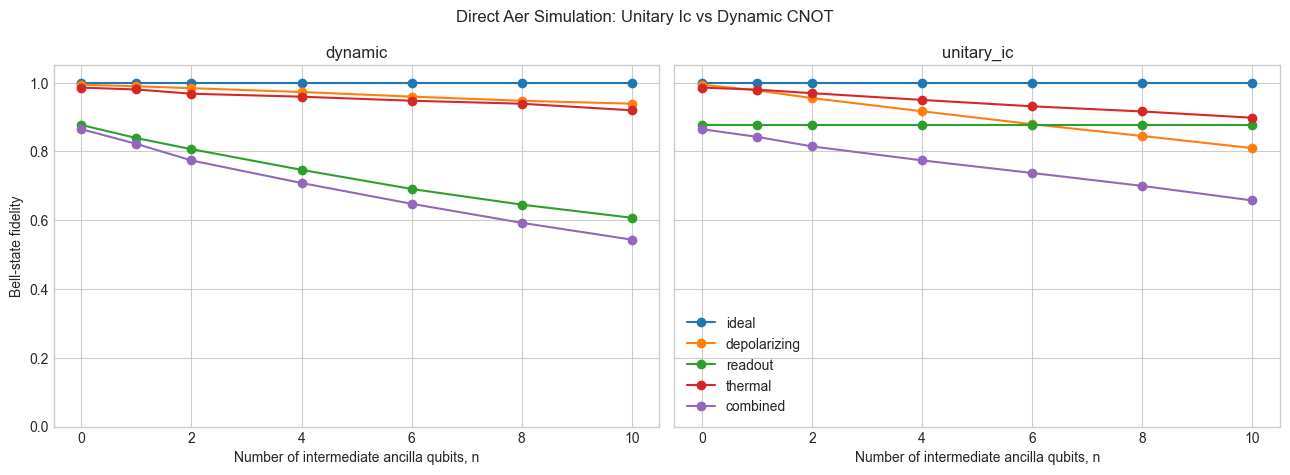

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

for ax, implementation in zip(axes, IMPLEMENTATIONS):
    subset = results_df[results_df["implementation"] == implementation]
    for noise_name, group in subset.groupby("noise_model", sort=False):
        ax.plot(group["n_ancilla"], group["fidelity"], marker="o", label=noise_name)
    ax.set_xlabel("Number of intermediate ancilla qubits, n")
    ax.set_title(implementation)
    ax.set_ylim(0.0, 1.05)

axes[0].set_ylabel("Bell-state fidelity")
axes[1].legend(loc="best")
plt.suptitle("Direct Aer Simulation: Unitary Ic vs Dynamic CNOT")
plt.tight_layout()
plt.show()

## Reference Error Budget: Table I

For the CNOT teleportation task, Appendix B.2 compares several unitary strategies. The paper argues that **unitary Ic** is the most relevant large-`n` unitary baseline because it removes idle error by paying extra CNOT gates.

Using Table I:

\[
\lambda_{\mathrm{unitary\ Ic}} = (4n+1)\lambda_{\mathrm{CNOT}}
\]

\[
\lambda_{\mathrm{dynamic}} = (2\mu+2)\lambda_{\mathrm{idle}} + (n+1)\lambda_{\mathrm{CNOT}} + n\lambda_{\mathrm{meas}}.
\]

The crossover condition follows by comparing the slopes in `n`: dynamic wins asymptotically when

\[
\lambda_{\mathrm{CNOT}} + \lambda_{\mathrm{meas}} < 4\lambda_{\mathrm{CNOT}}
\quad\Longleftrightarrow\quad
\lambda_{\mathrm{meas}} < 3\lambda_{\mathrm{CNOT}}.
\]

The constant dynamic offset `(2μ+2)λ_idle` delays the crossover at small distances.

In [55]:
def table_i_resources(n_ancilla: int, implementation: str, mu: float) -> dict:
    """Reference Table I resources for long-range CNOT teleportation."""
    n = n_ancilla
    if implementation == "unitary_ic":
        return {
            "implementation": implementation,
            "n_ancilla": n,
            "t_idle": 0.0,
            "N_CNOT": 4 * n + 1,
            "N_meas": 0,
            "two_qubit_depth": 2 * n + 1,
        }
    if implementation == "dynamic":
        return {
            "implementation": implementation,
            "n_ancilla": n,
            "t_idle": 2 * mu + 2,
            "N_CNOT": n + 1,
            "N_meas": n,
            "two_qubit_depth": 2 + mu,
        }
    raise ValueError(f"Unknown implementation: {implementation}")


resource_df = pd.DataFrame(
    table_i_resources(n, implementation, BUDGET_PARAMS["mu"])
    for implementation in IMPLEMENTATIONS
    for n in BUDGET_DISTANCES
)
resource_df

,implementation,n_ancilla,t_idle,N_CNOT,N_meas,two_qubit_depth
0,dynamic,0,9.54717,1,0,5.773585
1,dynamic,1,9.54717,2,1,5.773585
2,dynamic,2,9.54717,3,2,5.773585
3,dynamic,3,9.54717,4,3,5.773585
4,dynamic,4,9.54717,5,4,5.773585
...,...,...,...,...,...,...
77,unitary_ic,36,0.00000,145,0,73.000000
78,unitary_ic,37,0.00000,149,0,75.000000
79,unitary_ic,38,0.00000,153,0,77.000000
80,unitary_ic,39,0.00000,157,0,79.000000


In [56]:
def add_budget_terms(resource_df: pd.DataFrame, params: dict) -> pd.DataFrame:
    out = resource_df.copy()
    out["lambda_idle_term"] = out["t_idle"] * params["lambda_idle"]
    out["lambda_cnot_term"] = out["N_CNOT"] * params["lambda_cnot"]
    out["lambda_meas_term"] = out["N_meas"] * params["lambda_meas"]
    out["lambda_total"] = (
        out["lambda_idle_term"]
        + out["lambda_cnot_term"]
        + out["lambda_meas_term"]
    )
    out["process_fidelity_lower_bound"] = np.exp(-out["lambda_total"])
    return out


budget_df = add_budget_terms(resource_df, BUDGET_PARAMS)

pivot_budget = budget_df.pivot(
    index="n_ancilla",
    columns="implementation",
    values="process_fidelity_lower_bound",
).reset_index()
pivot_budget["dynamic_advantage"] = pivot_budget["dynamic"] > pivot_budget["unitary_ic"]

crossover_rows = pivot_budget[pivot_budget["dynamic_advantage"]]
crossover_n = None if crossover_rows.empty else int(crossover_rows.iloc[0]["n_ancilla"])
print(f"First budget crossover n: {crossover_n}")
print(
    "Asymptotic condition: "
    f"lambda_meas < 3*lambda_cnot is "
    f"{BUDGET_PARAMS['lambda_meas'] < 3 * BUDGET_PARAMS['lambda_cnot']}"
)

budget_df.head(), pivot_budget.head(), crossover_n

First budget crossover n: None
Asymptotic condition: lambda_meas < 3*lambda_cnot is False


(  implementation  n_ancilla   t_idle  N_CNOT  N_meas  two_qubit_depth  \
 0        dynamic          0  9.54717       1       0         5.773585   
 1        dynamic          1  9.54717       2       1         5.773585   
 2        dynamic          2  9.54717       3       2         5.773585   
 3        dynamic          3  9.54717       4       3         5.773585   
 4        dynamic          4  9.54717       5       4         5.773585   
 
    lambda_idle_term  lambda_cnot_term  lambda_meas_term  lambda_total  \
 0          0.027637          0.007571          0.000000      0.035208   
 1          0.027637          0.015142          0.042262      0.085042   
 2          0.027637          0.022714          0.084525      0.134875   
 3          0.027637          0.030285          0.126787      0.184709   
 4          0.027637          0.037856          0.169050      0.234543   
 
    process_fidelity_lower_bound  
 0                      0.965405  
 1                      0.918474  
 2 

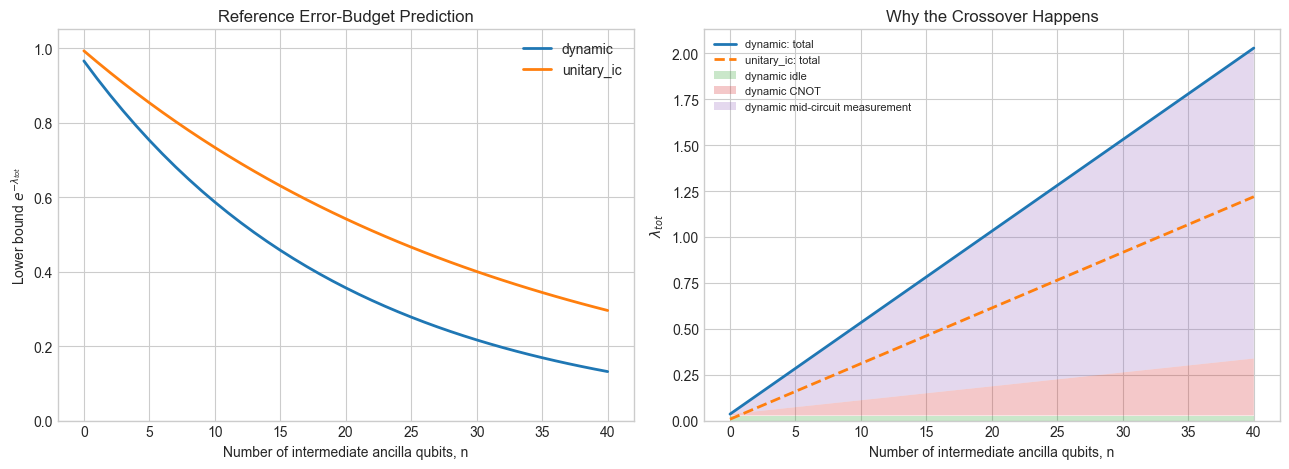

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for implementation, group in budget_df.groupby("implementation", sort=False):
    axes[0].plot(
        group["n_ancilla"],
        group["process_fidelity_lower_bound"],
        label=implementation,
        linewidth=2,
    )
axes[0].set_xlabel("Number of intermediate ancilla qubits, n")
axes[0].set_ylabel(r"Lower bound $e^{-\lambda_{tot}}$")
axes[0].set_ylim(0.0, 1.05)
axes[0].set_title("Reference Error-Budget Prediction")
axes[0].legend()
if crossover_n is not None:
    axes[0].axvline(crossover_n, color="k", linestyle="--", alpha=0.5)
    axes[0].text(crossover_n + 0.5, 0.95, f"crossover n={crossover_n}", va="top")

components = ["lambda_idle_term", "lambda_cnot_term", "lambda_meas_term"]
labels = ["idle", "CNOT", "mid-circuit measurement"]
for implementation, group in budget_df.groupby("implementation", sort=False):
    style = "-" if implementation == "dynamic" else "--"
    axes[1].plot(
        group["n_ancilla"],
        group["lambda_total"],
        linestyle=style,
        linewidth=2,
        label=f"{implementation}: total",
    )

# Show dynamic component breakdown; unitary Ic has only the CNOT term in Table I.
dyn_budget = budget_df[budget_df["implementation"] == "dynamic"]
axes[1].stackplot(
    dyn_budget["n_ancilla"],
    *(dyn_budget[col] for col in components),
    labels=[f"dynamic {label}" for label in labels],
    alpha=0.25,
)
axes[1].set_xlabel("Number of intermediate ancilla qubits, n")
axes[1].set_ylabel(r"$\lambda_{tot}$")
axes[1].set_title("Why the Crossover Happens")
axes[1].legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## Interpretation: Simulation vs Budget

The direct simulation answers which explicit Aer noise channel hurts the chosen circuits most under the selected parameters. The budget model answers the reference-style scaling question: when should dynamic beat unitary as `n` grows?

These are related but not identical. The budget's `N_meas` term counts the **additional mid-circuit measurements** of the dynamic protocol; final readout used for Bell-fidelity estimation is not part of Table I.

In [58]:
max_sim_distance = max(SIM_DISTANCES)
single_noise = results_df[results_df["noise_model"].isin(["depolarizing", "readout", "thermal"])]
at_max_distance = single_noise[single_noise["n_ancilla"] == max_sim_distance].copy()
at_max_distance = at_max_distance.sort_values(
    ["implementation", "infidelity"],
    ascending=[True, False],
)

dominant_by_implementation = at_max_distance.groupby("implementation").first().reset_index()
for row in dominant_by_implementation.itertuples(index=False):
    print(
        f"At simulated n={max_sim_distance}, {row.implementation} is most limited by "
        f"{row.noise_model} noise in this Aer sweep "
        f"(infidelity={row.infidelity:.4f})."
    )

combined_sim = results_df[
    (results_df["noise_model"] == "combined")
    & (results_df["n_ancilla"] == max_sim_distance)
][["implementation", "fidelity", "infidelity"]]

budget_at_sim_max = budget_df[budget_df["n_ancilla"] == max_sim_distance][
    ["implementation", "lambda_total", "process_fidelity_lower_bound"]
]

print("\nCombined-noise simulation at the largest simulated distance:")
display(combined_sim)
print("Reference budget at the same distance:")
display(budget_at_sim_max)
print(f"\nReference-budget crossover n: {crossover_n}")

at_max_distance[["implementation", "noise_model", "fidelity", "infidelity"]]

At simulated n=10, dynamic is most limited by readout noise in this Aer sweep (infidelity=0.3928).
At simulated n=10, unitary_ic is most limited by depolarizing noise in this Aer sweep (infidelity=0.1903).

Combined-noise simulation at the largest simulated distance:


,implementation,fidelity,infidelity
34,dynamic,0.543579,0.456421
69,unitary_ic,0.657471,0.342529


Reference budget at the same distance:


,implementation,lambda_total,process_fidelity_lower_bound
10,dynamic,0.533545,0.586522
51,unitary_ic,0.310421,0.733138



Reference-budget crossover n: None


,implementation,noise_model,fidelity,infidelity
20,dynamic,readout,0.607178,0.392822
27,dynamic,thermal,0.919678,0.080322
13,dynamic,depolarizing,0.938965,0.061035
48,unitary_ic,depolarizing,0.809692,0.190308
55,unitary_ic,readout,0.877075,0.122925
62,unitary_ic,thermal,0.898071,0.101929


## Report-Writing Notes

A concise Problem 3 interpretation can be written as follows:

- In the unitary Ic baseline, the dominant scaling term is CNOT error because `N_CNOT = 4n + 1`. It has no mid-circuit measurement term and no Table-I idle term.
- In the dynamic circuit, CNOT cost is reduced to `n + 1`, but the protocol pays `n` mid-circuit measurements and a constant idle/feed-forward offset `(2μ + 2)λ_idle`.
- Therefore dynamic circuits are not automatically better. They become favorable at large distance only when mid-circuit measurement error is sufficiently low, approximately `λ_meas < 3λ_CNOT`.
- With the reference Fig. 7 parameters used here, `λ_meas = 0.03` and `3λ_CNOT = 0.06`, so the asymptotic condition is satisfied. The finite-`n` crossover is delayed by the dynamic idle/feed-forward offset.
- The Aer noise sweep is a separate numerical check. It includes final readout used for fidelity estimation, while the reference budget counts only protocol resources. Use it to identify sensitivity to depolarizing, readout, and thermal noise, but use Table I for the unitary-vs-dynamic scaling argument.

For a backend-specific submission, replace `NOISE_PARAMS` and `BUDGET_PARAMS` with calibrated backend values, especially mid-circuit measurement error and feed-forward time `μ`.